# Annotations & Overlays

A bare image is *data*; a richer figure contains data plus the **furniture** that lets a reader
trust and measure it — a synthesized beam, a scale bar, a compass, band labels, a
reticle on the target, a ruler along a feature. This tutorial is the annotation
toolkit that turns the one into the other, answering the two questions every
annotation raises: **"how do I add this?"** and **"how do I adjust it?"**

> **Note:** we call these elements *furniture* rather than *decoration* to keep them
> distinct from a frame's *own* ticks, grids, spines, and labels — styling those is
> the subject of [Decorating Frames](decorating_frames.ipynb).

We build the toolkit piece by piece on real images. The running canvas is the VLBA
jet of **3C 84** (the radio core of NGC 1275 in the Perseus cluster), a field only
~0.1 arcseconds across — small enough that the annotations naturally work in
milliarcseconds and a ruler reads out in parsecs. [Section 1](#1.-Furniture) is the
**furniture** (beams, scale bars, band labels, compasses, orientation indicators);
[Section 2](#2.-Measurement-tools) is the **measurement tools** (reticles and rulers,
and how they read the coordinates you hand them); and the
[capstone](#3.-Putting-it-together) furnishes a completely different image from
scratch — the ALMA view of **SN 1987A**.

> **Scope:** this is the annotation *layer*. Adjusting the image *underneath* it —
> stretch, colorbar scaling, contour levels — is
> [FITS Images & Quicklook](fits_images.ipynb); the frame's own ticks, grids, and
> labels are [Decorating Frames](decorating_frames.ipynb); drawing a second
> coordinate *grid* is [Overlay Coordinate Grids](overlay_grids.ipynb).

## Contents

1. [Furniture](#1.-Furniture)
2. [Measurement tools](#2.-Measurement-tools)
3. [Putting it together](#3.-Putting-it-together)
4. [Where to go next](#4.-Where-to-go-next)

In [1]:
import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from astropy.coordinates import SkyCoord
from astropy.io import fits
from astropy.wcs import WCS
from reproject import reproject_interp

import skyplothelper as sph

# base='structural' tightens frame and tick geometry only — it touches no colors or
# fonts, so it layers cleanly under any theme you choose to set. The full styling
# system is the Themes, Palettes & Fonts tutorial's story.
sph.set_style(base="structural")

Throughout, the recurring canvas is the bundled **3C 84** VLBA image
(`0316+413.u.stacked.icd.fits`) — a 15 GHz (Ku-band) map with a bright core and a
one-sided jet streaming south. We load it once and display it on its own WCS.
Because the field is only milliarcseconds wide, the annotations naturally work in
`mas`/`μas`, and the source's distance lets a ruler read out *parsecs*.

In [2]:
FITS_3C84 = "../../examples/data/0316+413.u.stacked.icd.fits"
_data, _hdr = fits.getdata(FITS_3C84, header=True)
_data = np.squeeze(_data)                       # drop the degenerate FREQ/STOKES axes

# The archival header carries DATE-OBS='MULTIEPOCH' (a stacked image, not one date),
# which is not a valid FITS date — drop it on a copy so building the WCS is silent.
_hdr_wcs = _hdr.copy()
_hdr_wcs.pop("DATE-OBS", None)
_WCS = WCS(_hdr_wcs).celestial

# The core is the brightest pixel; the jet runs south from it. These anchor the
# reticle and ruler later.
_cy, _cx = np.unravel_index(np.nanargmax(_data), _data.shape)
_core_world = _WCS.pixel_to_world(_cx, _cy)
CORE = (_core_world.ra.deg, _core_world.dec.deg)
_PEAK = float(np.nanmax(_data))                 # ~3 Jy/beam — sets the stretch ceiling
PERSEUS_Z = 0.0176                              # NGC 1275 redshift → physical scale

# A square crop framing the core + jet (~26 mas across).
CROP = (_cx - 130, _cx + 130, _cy - 130, _cy + 130)


def mojave_norm():
    """The 3C 84 display the FITS Images & Quicklook tutorial settled on: a
    symmetric-log stretch, linear within ~5 mJy of zero and logarithmic out to the
    ~3 Jy peak, matching the look the MOJAVE survey publishes. It shows the bright core
    and the faint extended jet at once — we reuse it here so the annotations sit on the
    same picture readers meet there."""
    return sph.make_norm(stretch="symlog", clip="manual", vmin=0.0, vmax=_PEAK, a=5e-3)

# Colors for the annotation objects come from skyplothelper's own registries. These
# images are dark whatever the page looks like, so objects drawn over them (reticles,
# beams, the compass) pull from the dark-background annotation palette; the dual-mode
# uranometria cycle palette supplies series-like families (multi-band beams, rulers on
# plain frames). Pure highlighting — scale bars, a band's own contours — stays white.
PAL = sph.ANNOTATION_PALETTES["dark"]           # role-keyed: accent, accent2, compass, ...
URAN = sph.CYCLE_PALETTES["uranometria"]["colors"]
C_RETICLE = PAL["accent"]      # bright gold — reticles and their labels
C_COMPASS = PAL["compass"]     # sage — the palette's designated compass role
C_BEAM = PAL["accent2"]        # terracotta — beam ellipses
C_BAND9 = URAN[4]              # teal — the capstone's second band (679 GHz)


def stroke(lw, color="black"):
    """A path-effect stroke — the cartographic trick that keeps text and thin lines
    legible against busy structure."""
    return [pe.withStroke(linewidth=lw, foreground=color)]


def image_ruler(ax, xy1, xy2, **kw):
    """A white ruler for use over the dark image, placed in *pixel* coordinates.

    Ruler strokes its own line; the tick labels and title need the same help over
    bright structure, so we add a dark stroke to the text after drawing."""
    # These rulers are positioned against image features, so they are pinned to pixel
    # coordinates. On a sky frame a bare numeric tuple would otherwise be read as
    # degrees — see the coordinate-input section below.
    kw.setdefault("coord_type", "pixel")
    kw.setdefault("color", "white")
    kw.setdefault("label_color", "white")
    kw.setdefault("stroke_color", "black")
    kw.setdefault("stroke_lw", 2.2)
    kw.setdefault("label_fontsize", 8)
    kw.setdefault("n_ticks", 4)
    # Slightly longer than the default so the minor ticks (half this length) still read
    # at figure scale; harmless when a ruler asks for no minors.
    kw.setdefault("tick_length", 5.5)
    kw.setdefault("minor_tick_length", 3.0)
    r = sph.Ruler(xy1, xy2, ax=ax, **kw).add_to(ax)
    texts = list(r.label_artists)
    if getattr(r, "title_artist", None) is not None:
        texts.append(r.title_artist)
    for t in texts:
        t.set_path_effects(stroke(2.0))
    return r


def show_3c84(subplot=111, fig=None, crop=CROP, cmap="sph.deepsky"):
    """Display the 3C 84 jet on its own WCS — the tutorial's recurring canvas.

    Uses the same symmetric-log stretch and deepsky colormap the FITS Images &
    Quicklook tutorial settled on for this image; adjusting an image's scaling
    (stretch, colorbars, contour levels) is that tutorial's story."""
    if fig is None:
        fig = plt.figure(figsize=(6, 6))
    args = subplot if isinstance(subplot, tuple) else (subplot,)
    ax = fig.add_subplot(*args, projection=_WCS)
    ax.imshow(_data, origin="lower", cmap=cmap, norm=mojave_norm())
    x0, x1, y0, y1 = crop
    ax.set_xlim(x0, x1)
    ax.set_ylim(y0, y1)
    # Tidy the absolute-coordinate axes: this is a mas-scale field, so keep the tick
    # labels few and small. (For relative 'mas-from-core' offset axes, that's the
    # offset-tick tool in Decorating Frames.)
    for ci, name in ((0, "Right Ascension"), (1, "Declination")):
        ax.coords[ci].set_axislabel(name, fontsize=9)
        ax.coords[ci].set_ticklabel(fontsize=7)
        ax.coords[ci].set_ticks(number=3)
    ax.figure.canvas.draw()
    return ax

Here is the destination — every piece of furniture and every measurement tool on the
3C 84 jet at once: a synthesized **beam** (lower left), an angular **scale bar** and a
**compass**, a **colorbar** for the brightness, a **reticle** on the core, and a
**ruler** reading the jet in projected parsecs. It looks like a lot; each piece is a
single call, and the rest of this tutorial builds them up one at a time.

> **Note:** the colorbar comes from `add_colorbar`, which sizes its bar to the
> *rendered image* (a fixed-aspect WCS frame trips plain `plt.colorbar` into sizing
> against the whole axes box). Its placement modes (`mode='divider'/'inset'/'simple'`)
> and the rest of the colorbar story live in
> [FITS Images & Quicklook](fits_images.ipynb).

Text(0.5, 1.0, '3C 84 — a fully furnished VLBI image')

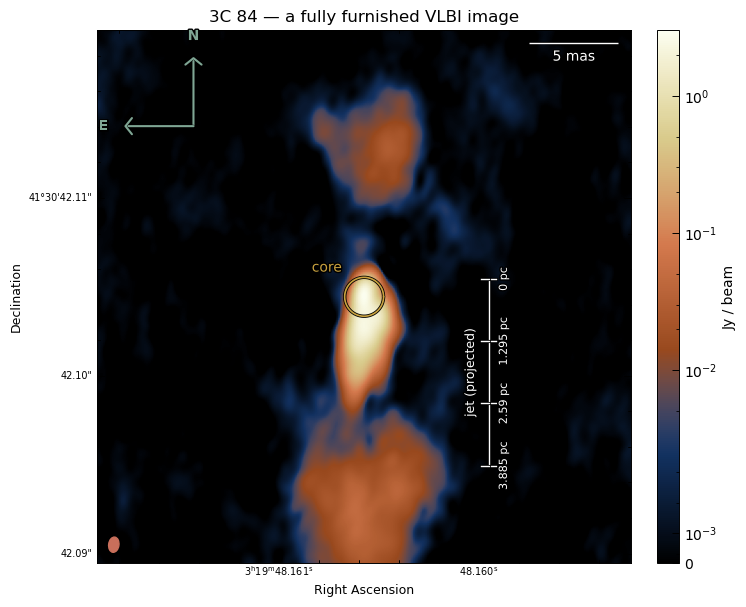

In [3]:
# fig-slug: overview
fig = plt.figure(figsize=(7.5, 7))
ax = show_3c84(111, fig=fig, crop=(_cx - 150, _cx + 150, _cy - 150, _cy + 150))

sph.Beam.from_header(_hdr, ax=ax, style="ellipse", fc=C_BEAM,
                     ec=C_BEAM).add_anchored(ax, loc="lower left")
sph.add_sizebar_asec(ax, _hdr, length_asec=0.005, label="5 mas", color="white", loc=1)
sph.add_compass(ax, loc="upper left", color=C_COMPASS, stroke_color="black", length=0.13)
sph.add_colorbar(ax.images[0], ax=ax, label="Jy / beam")
sph.add_reticle(ax, CORE, style="circle", size=14, color=C_RETICLE, stroke_color="black",
                label="core", label_color=C_RETICLE,
                label_kwargs=dict(path_effects=stroke(2.0)))
image_ruler(ax, (_cx + 70, _cy + 10), (_cx + 70, _cy - 95),
            convert=dict(redshift=PERSEUS_Z, unit="pc"),
            title="jet (projected)", title_fontsize=9, title_color="white")
ax.set_title("3C 84 — a fully furnished VLBI image", fontsize=12)

## 1. Furniture

Furniture is the non-data layer a publication figure needs to be *read*: the beam
that says "this is the resolution," the bar that says "this is the scale," the
compass that says "this is the orientation," the band labels that say "this is the
channel." Each takes the axes as its first argument and is one call.

### Beams

The synthesized **beam** (the point-spread function of an interferometer) is the
single most important piece of furniture on a radio map: it is the scale below
which structure is not resolved. `Beam` is a skyplothelper-wrapped matplotlib patch with constructors for
each starting point — most often `Beam.from_header`, which reads `BMAJ`/`BMIN`/`BPA`
straight from the FITS header and converts the position angle from the FITS
convention (east of north) for you. `.add_anchored()` parks it in a corner, the
typical placement.

Text(0.5, 1.0, 'Beam.from_header — the synthesized beam, corner-anchored')

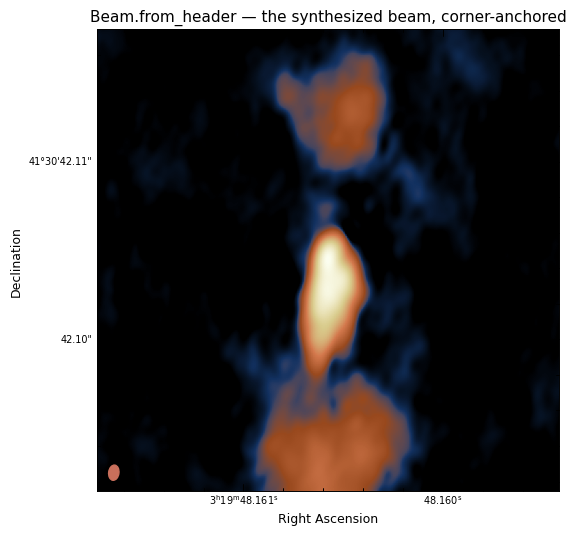

In [4]:
ax = show_3c84()
beam = sph.Beam.from_header(_hdr, ax=ax, style="ellipse", fc=C_BEAM, ec=C_BEAM)
beam.add_anchored(ax, loc="lower left")
ax.set_title("Beam.from_header — the synthesized beam, corner-anchored", fontsize=11)

**The other ways in, and the knobs.** When you have the numbers but no header, use
`Beam.from_arcsec(bmaj, bmin, bpa_deg=, pixscale_asec=)`; `Beam.from_psf_fit` fits
the beam from a PSF image. The `style=` argument switches the look — a plain
`'ellipse'`, a `'crosshair'` (major/minor axis lines), the `'*grid'` hatched
variants, or `'filled'` — and every component is independently colorable
(`fc`/`ec`/`lw`/`ls`, `.set_crosshair(...)`, `.set_grid(...)`). Here are the six
styles side by side on identical geometry, so only the display differs:

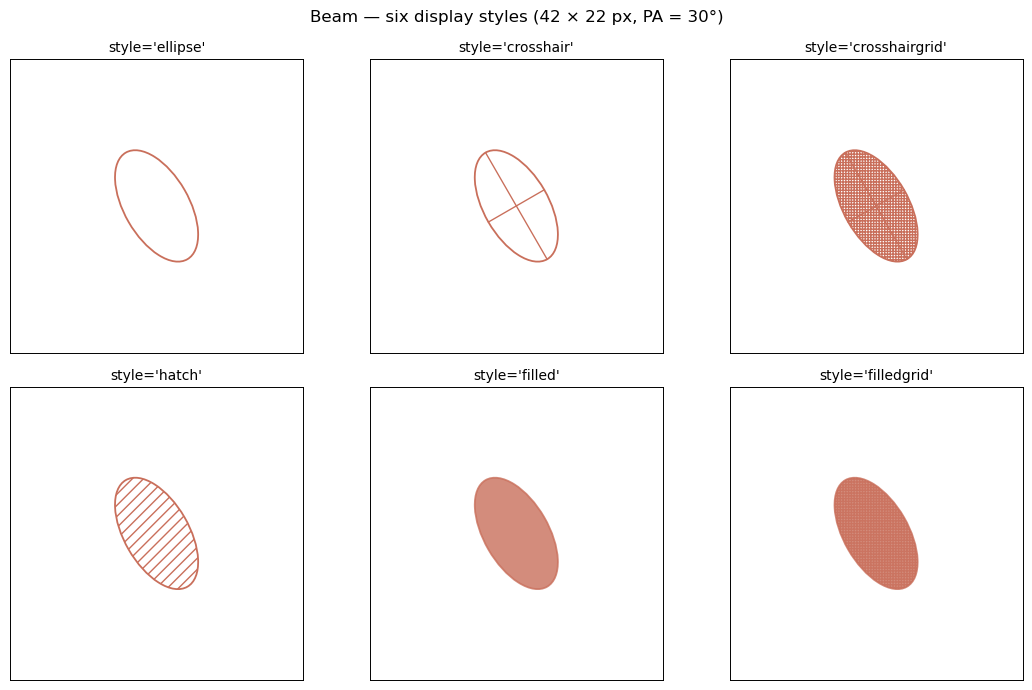

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(11, 7))
styles = ["ellipse", "crosshair", "crosshairgrid", "hatch", "filled", "filledgrid"]
for axb, style in zip(axes.flat, styles):
    axb.set_aspect("equal")
    axb.set_xlim(0, 100)
    axb.set_ylim(0, 100)
    axb.set_xticks([])
    axb.set_yticks([])
    sph.Beam((50, 50), bmaj_pix=42, bmin_pix=22, bpa_deg=30, style=style,
             ec=C_BEAM, lw=1.3).add_to(axb)
    axb.set_title(f"style={style!r}", fontsize=10)
fig.suptitle("Beam — six display styles (42 × 22 px, PA = 30°)", fontsize=12)
fig.tight_layout()

**Several beams at once.** Multi-band figures need one beam *per* band; `BeamStack`
lays them out together in a single anchored box, and `Beam.add_psf_inset` puts a
beam in its own inset panel. Here a stack of three nominal VLA beams (sizes shrink
toward higher frequency) in the corner of the jet field.

Text(0.5, 1.0, 'BeamStack — one beam per band (C / X / K), nested')

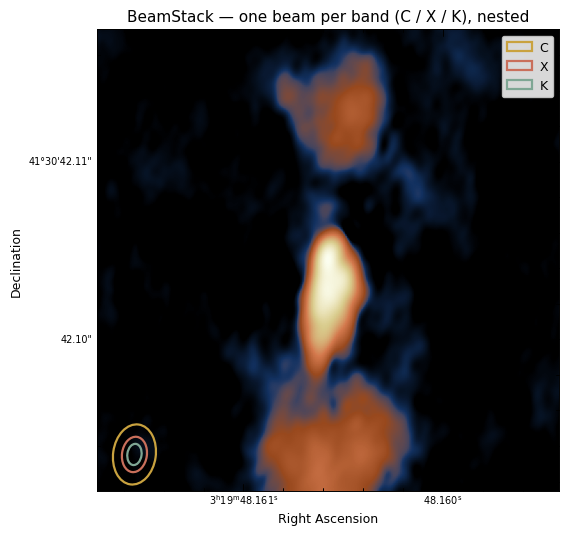

In [6]:
ax = show_3c84()
_aspp = abs(_hdr_wcs["CDELT2"]) * 3600.0        # arcsec per pixel
# Three nominal band beams (sizes in arcsec → pixels), largest first, each in its own
# dark-background palette hue so the nested outlines stay tellable-apart.
specs = [dict(bmaj_pix=0.0034 / _aspp, bmin_pix=0.0024 / _aspp, bpa_deg=-8, ec=PAL["accent"], label="C"),
         dict(bmaj_pix=0.0020 / _aspp, bmin_pix=0.0014 / _aspp, bpa_deg=-8, ec=PAL["accent2"], label="X"),
         dict(bmaj_pix=0.0012 / _aspp, bmin_pix=0.0008 / _aspp, bpa_deg=-8, ec=PAL["compass"], label="K")]
sph.BeamStack.from_specs(specs, ax=ax, fc="none", lw=1.6).add_to(ax)
# Legend in the opposite corner from the (lower-left) nested beams.
ax.legend(loc="upper right", fontsize=9, framealpha=0.85)
ax.set_title("BeamStack — one beam per band (C / X / K), nested", fontsize=11)

The band labels above use a plain matplotlib legend (`ax.legend()`) — the right tool
for one dimension. When a figure keys *several* channels at once — color for one
quantity, marker size for another — skyplothelper's `MultiLegend` builds a stacked,
off-frame legend with one block per channel, so each scale is read on its own. It is
the same kind of figure furniture as everything else here; its full tour lives in
[Catalogs — Querying, Plotting and Searching](catalogs.ipynb#2.-Legends-for-multiple-dimensions).

> **Note:** the header helpers `beampars_asec_fromhdr`, `pixperbeam_from_hdr`, and
> `pixperbeam_from_pars` return the beam *numbers* (sizes, pixels-per-beam) without
> drawing anything — useful for flux-density bookkeeping.

### Scale bars

A **scale bar** states the angular size of a span directly on the image. Two forms:
`add_sizebar_asec(ax, hdr, length_asec=, label=)` sizes the bar from the header's
pixel scale — give it a physical length and a label and it works out the pixel
length; `add_sizebar(ax, length_pixels=, label=)` is the general pixel-units form
when you have no header. Both anchor in a corner like the beam.

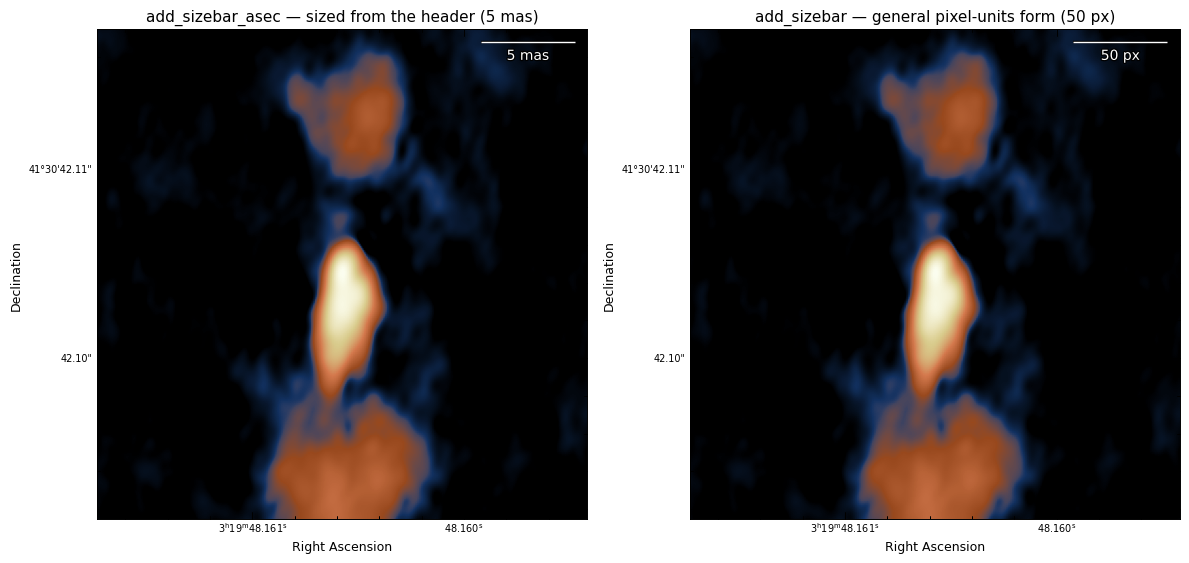

In [7]:
fig = plt.figure(figsize=(12, 6))

ax1 = show_3c84((1, 2, 1), fig=fig)
sph.add_sizebar_asec(ax1, _hdr, length_asec=0.005, label="5 mas",
                     color="white", loc=1)
ax1.set_title("add_sizebar_asec — sized from the header (5 mas)", fontsize=11)

ax2 = show_3c84((1, 2, 2), fig=fig)
sph.add_sizebar(ax2, length_pixels=50, label="50 px", color="white", loc=1)
ax2.set_title("add_sizebar — general pixel-units form (50 px)", fontsize=11)

fig.tight_layout()

> **Note:** these are *angular* scale bars (arcsec / pixels). The **distance** scale
> bars on globes — kilometers across a planet's surface — are a separate tool in
> [Globe and Planet Plotting](globe_plots.ipynb).

### Band labels

Multi-band and multi-epoch figures need each panel (or each channel of a composite)
labeled with which band it is, color-matched to the data. `add_bandlabels(ax,
labels, labcolors)` stacks corner labels for exactly that. skyplothelper also ships
the band/facility reference tables those labels draw on:

In [8]:
# The registries are dicts you can read directly.
print("RADIO_BANDS  (key → GHz range):")
for k in ["L", "C", "X", "Ku", "K"]:
    lo, hi = sph.RADIO_BANDS[k]
    print(f"   {k:3s} {lo:6.2f} – {hi:5.1f} GHz")
print("\nFILTER_BANDS  (key → center / width / system):")
for k in ["U", "B", "V", "g", "r"]:
    b = sph.FILTER_BANDS[k]
    print(f"   {k:3s} {b['center_nm']:4d} nm  ±{b['width_nm']:3d}  ({b['system']})")
print(f"\nRADIO_BANDS: {len(sph.RADIO_BANDS)} bands · "
      f"FILTER_BANDS: {len(sph.FILTER_BANDS)} · "
      f"FACILITY_RESOLUTION: {len(sph.FACILITY_RESOLUTION)} facility/config entries")

RADIO_BANDS  (key → GHz range):
   L     1.00 –   2.0 GHz
   C     4.00 –   8.0 GHz
   X     8.00 –  12.0 GHz
   Ku   12.00 –  18.0 GHz
   K    18.00 –  26.5 GHz

FILTER_BANDS  (key → center / width / system):
   U    365 nm  ± 66  (Johnson)
   B    445 nm  ± 94  (Johnson)
   V    551 nm  ± 88  (Johnson)
   g    477 nm  ±138  (SDSS)
   r    623 nm  ±138  (SDSS)

RADIO_BANDS: 12 bands · FILTER_BANDS: 38 · FACILITY_RESOLUTION: 40 facility/config entries


**The reference tables, by family.** Pull names, frequencies, and nominal
resolutions from these rather than hard-coding them:

| Registry | Keyed by | Each entry holds | Typical use |
| --- | --- | --- | --- |
| `RADIO_BANDS` | radio band letter (`L`, `C`, `X`, `K`, …) | `(freq_lo, freq_hi)` in GHz | label a radio map's band; pick a representative frequency |
| `FILTER_BANDS` | photometric filter (`U`, `B`, `V`, `g`, `r`, …) | `center_nm`, `width_nm`, `system` | label optical/IR composite channels |
| `FACILITY_RESOLUTION` | facility + config + band key | `resolution_asec`, `band`, `note` | annotate or sanity-check a map's resolution |

> **Note:** our 3C 84 image's own 15 GHz band is **`Ku`** in `RADIO_BANDS`. You will
> also see it written **`U`** — a colloquial VLBI shorthand for Ku-band (it is why
> the file is named `0316+413.u.stacked...`). `U` is *not* a standard `RADIO_BANDS`
> key, though; use `Ku` instead.

Here a three-color composite — three offset sources, one per channel — with each
band labeled in its channel's color (the standard multicolor-composite pattern):

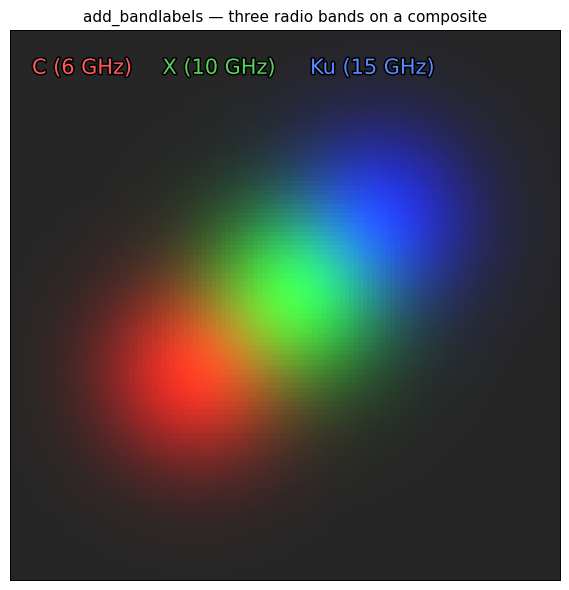

In [9]:
fig, ax = plt.subplots(figsize=(6, 6))
ny, nx = 120, 120
yy, xx = np.mgrid[0:ny, 0:nx]


def _blob(cx, cy, s=14.0):
    return np.exp(-((xx - cx) ** 2 + (yy - cy) ** 2) / (2 * s ** 2))


# Each radio band contributes one source at a different position.
R = 0.15 + 0.85 * _blob(40, 45)        # C-band
G = 0.15 + 0.85 * _blob(62, 62)        # X-band
B = 0.15 + 0.85 * _blob(80, 78)        # U-band
ax.imshow(np.clip(np.dstack([R, G, B]), 0, 1), origin="lower")
ax.set_xticks([])
ax.set_yticks([])

band_colors = ["#ff5a5a", "#5ad15a", "#5a8aff"]
labels = [f"{k} ({np.mean(sph.RADIO_BANDS[k]):.0f} GHz)" for k in ("C", "X", "Ku")]
sph.add_bandlabels(ax, labels=labels, labcolors=band_colors, fontsize=15,
                   xy=(0.04, 0.95), textpad=0.31)
for txt in ax.texts[-3:]:                # add_bandlabels takes no stroke kwarg — apply here
    txt.set_path_effects(stroke(2.2))
ax.set_title("add_bandlabels — three radio bands on a composite", fontsize=11)
fig.tight_layout()

Another common multi-image figure shape is the **panel row** — one cutout per band or epoch, each
tagged in its corner. That is the same call with a single label per panel; keeping
each label in its channel's color ties the row back to the composite above:

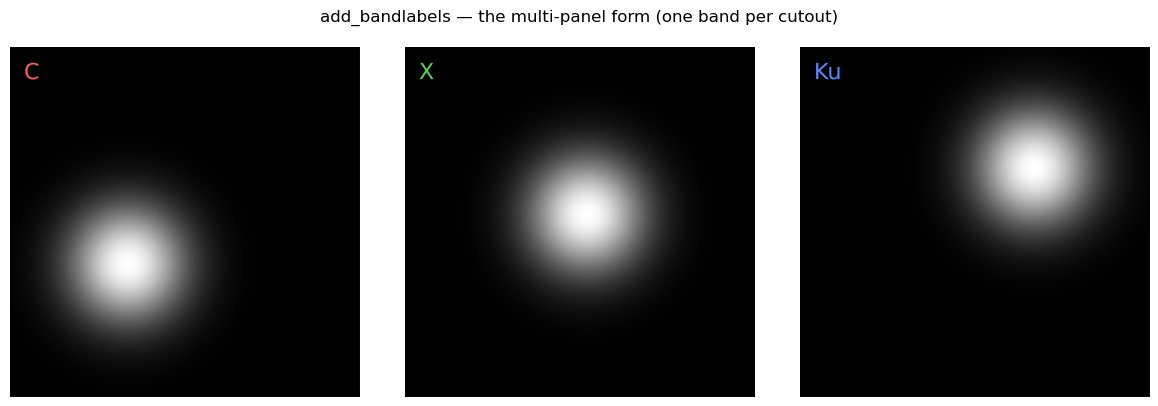

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4.1))
for axp, chan, band, col in zip(axes, (R, G, B), ("C", "X", "Ku"), band_colors):
    axp.imshow(chan, origin="lower", cmap="gray")
    axp.set_xticks([])
    axp.set_yticks([])
    sph.add_bandlabels(axp, labels=[band], labcolors=[col], fontsize=16)
    axp.texts[-1].set_path_effects(stroke(2.2))
fig.suptitle("add_bandlabels — the multi-panel form (one band per cutout)", fontsize=12)
fig.tight_layout()

### Compass and orientation

A **compass** marks which way is north and east. `add_compass` reads the axes' WCS,
so it points correctly even when the image is *not* north-up — the common case of
an instrument aligned with its own detector rather than to the sky coordinate grid.

To show that honestly we need a genuinely rotated image, not just a relabeled one:
below, the right panel is the same patch of sky **resampled onto a detector artificially turned
30° by us**, so the jet itself leans over. The RA/Dec grid (drawn in both panels in the
compass color) makes the rotation unmistakable — straight and square on the left,
tilted on the right — and the compass follows it without being told.

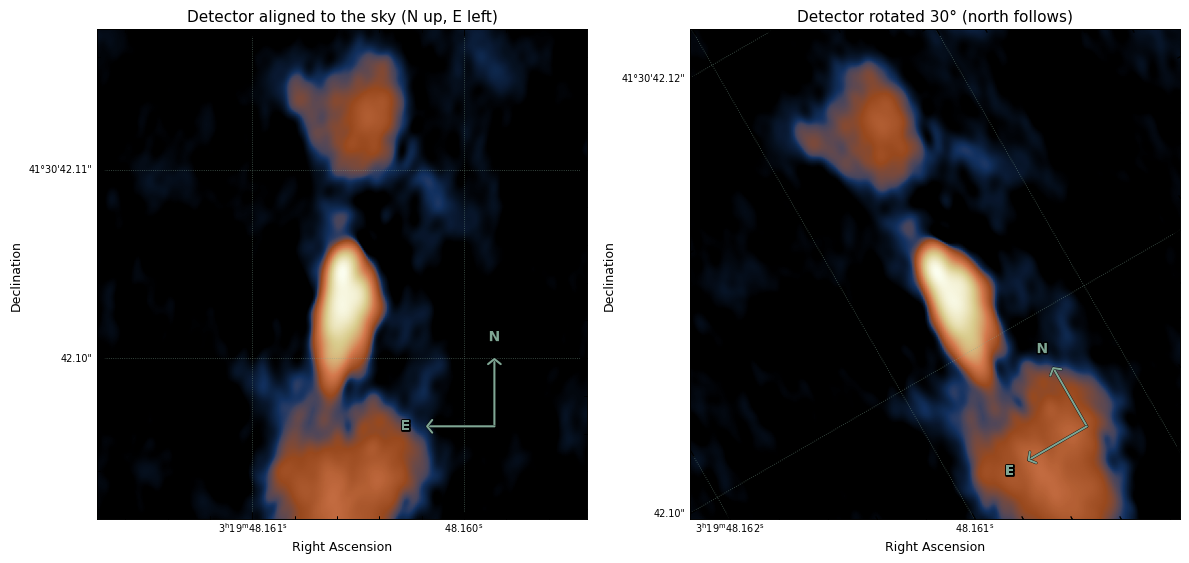

In [11]:
fig = plt.figure(figsize=(12, 6))

ax1 = show_3c84((1, 2, 1), fig=fig)
ax1.coords.grid(color=C_COMPASS, alpha=0.55, lw=0.6, ls=":")
sph.add_compass(ax1, loc="lower right", color=C_COMPASS, stroke_color="black", length=0.14)
ax1.set_title("Detector aligned to the sky (N up, E left)", fontsize=11)

# Build a WCS for a detector rotated 30° on the sky, then resample the image onto it —
# the pixels really move, which is what a rotated detector would record.
rot = np.radians(30.0)
cs, sn = np.cos(rot), np.sin(rot)
wcs_rot = _WCS.deepcopy()
cd = np.array(_WCS.wcs.cd if _WCS.wcs.has_cd()
              else np.diag(_WCS.wcs.cdelt) @ _WCS.wcs.get_pc())
wcs_rot.wcs.cd = np.array([[cs, -sn], [sn, cs]]) @ cd
rot_data, _ = reproject_interp((_data, _WCS), wcs_rot, shape_out=_data.shape)

ax2 = fig.add_subplot(1, 2, 2, projection=wcs_rot)
ax2.imshow(rot_data, origin="lower", cmap="sph.deepsky", norm=mojave_norm())
ax2.set_xlim(*CROP[:2])
ax2.set_ylim(*CROP[2:])
for ci, name in ((0, "Right Ascension"), (1, "Declination")):
    ax2.coords[ci].set_axislabel(name, fontsize=9)
    ax2.coords[ci].set_ticklabel(fontsize=7)
    ax2.coords[ci].set_ticks(number=3)
ax2.coords.grid(color=C_COMPASS, alpha=0.55, lw=0.6, ls=":")
ax2.figure.canvas.draw()
sph.add_compass(ax2, loc="lower right", color=C_COMPASS, stroke_color="black", length=0.14)
ax2.set_title("Detector rotated 30° (north follows)", fontsize=11)

fig.tight_layout()

For a compact **orientation indicator** rather than a corner compass,
`add_axis_inlay` draws a small wireframe of the *projection outline* with arrows
along the longitude and latitude axes. It earns its keep on all-sky and globe
frames, where "which way does longitude run?" is genuinely ambiguous: sky maps
read east-*left* (the inlay detects this from the WCS and flips the arrow), while
Earth-style maps read east-right (`lon_invert=False`). The labels are free text, so
the same indicator serves RA/Dec, Earth lon/lat, or galactic ℓ/b:

Text(0.5, 1.0, 'add_axis_inlay — the projection outline + axis directions,\nfor sky (east-left) and Earth (east-right) conventions')

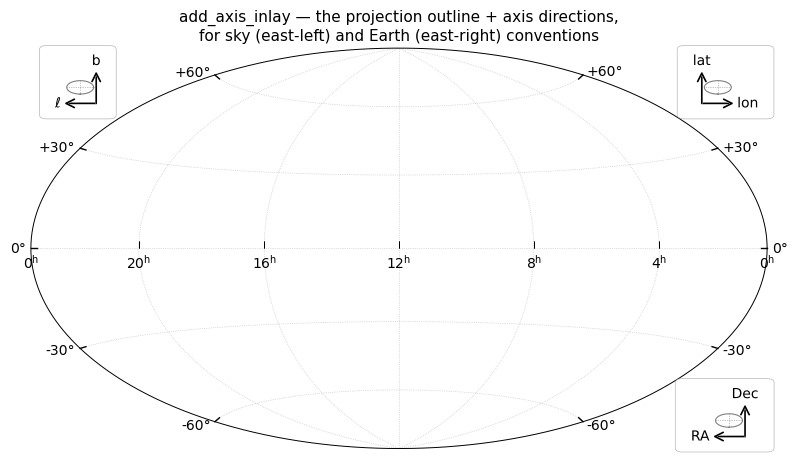

In [12]:
fig = plt.figure(figsize=(9.5, 5.2))
ax = sph.make_wcs_frame(111, "AIT", center=180, fig=fig)
fig.canvas.draw()
# Auto-detected from the WCS: RA increases leftward, so the lon arrow flips.
sph.add_axis_inlay(ax, lon_label="RA", lat_label="Dec", loc="lower right")
# Earth-style map convention, forced: longitude arrow points right.
sph.add_axis_inlay(ax, lon_label="lon", lat_label="lat", loc="upper right",
                   lon_invert=False)
# Galactic labels, sky convention.
sph.add_axis_inlay(ax, lon_label="ℓ", lat_label="b", loc="upper left",
                   lon_invert=True)
ax.set_title("add_axis_inlay — the projection outline + axis directions,\n"
             "for sky (east-left) and Earth (east-right) conventions", fontsize=11)

### Instrument markers

For *site* maps — where the dishes or telescopes are — there are procedurally drawn
instrument markers bundled with skyplothelper: `add_antenna_marker` (a radio dish with pointable elevation),
`add_telescope_marker` (a cartoon refractor on a tripod), and `add_dome_marker` (an
observatory dome with a positionable slit). No image files needed, and every part is
colorable — `face_color`, `edge_color`, and a `stroke_color` for busy backgrounds.

Because every part is a color you choose, the same markers suit a white journal page
or a dark talk slide. Here the two rows are the *same three calls*, with colors and
backgrounds pulled from the light (`publication`) and dark (`dark`) annotation
palettes:

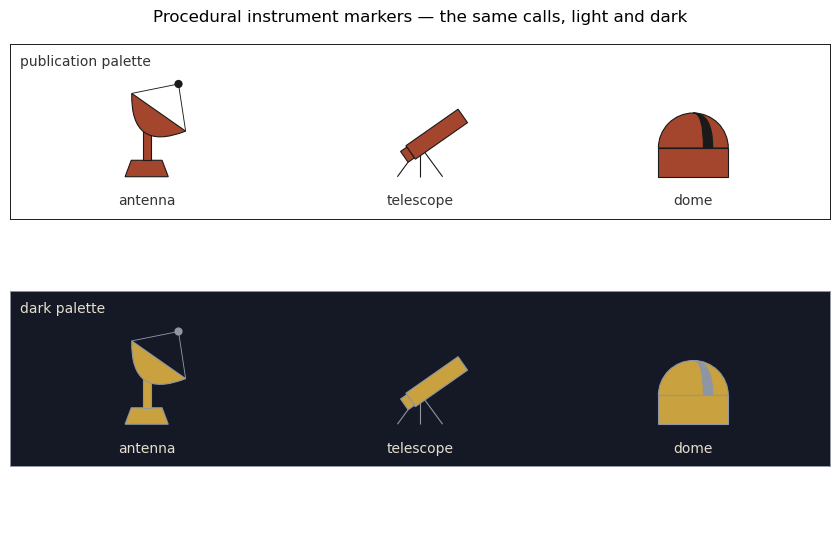

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(8.5, 5.4))
markers = [(sph.add_antenna_marker, dict(dish_elev=55), "antenna"),
           (sph.add_telescope_marker, dict(tube_elev=35), "telescope"),
           (sph.add_dome_marker, dict(slit_azim=25), "dome")]

for axm, pal_name in zip(axes, ("publication", "dark")):
    p = sph.ANNOTATION_PALETTES[pal_name]
    axm.set_xlim(0, 3)
    axm.set_ylim(0, 1)
    axm.set_xticks([])
    axm.set_yticks([])
    axm.set_facecolor(p["ax_bg"])
    for spine in axm.spines.values():
        spine.set_color(p["frame"])
    for i, (fn, kw, name) in enumerate(markers):
        # Markers are base-anchored — their feet sit on the given point and they stand
        # up from it — so we place the feet on a common low baseline and let the panel
        # label take the clear space above.
        fn(axm, (i + 0.5, 0.24), size=74, face_color=p["accent"],
           edge_color=p["frame"], **kw)
        axm.text(i + 0.5, 0.08, name, ha="center", fontsize=10, color=p["text"])
    # Label inside the panel, so it sits on that palette's own background rather than
    # on the page (where a light-palette label would vanish on a dark page, and vice
    # versa).
    axm.text(0.012, 0.94, f"{pal_name} palette", transform=axm.transAxes,
             fontsize=10, color=p["text"], ha="left", va="top")
fig.suptitle("Procedural instrument markers — the same calls, light and dark",
             fontsize=12)
fig.tight_layout()

> **Note:** these are a brief taste. Instrument markers are *rotatable markers* —
> the same family as image stamps (antenna photos, planet icons, the Sun) — and get
> their full treatment, including placement on globes, in
> [Markers — Rotatable and Image Stamps](markers.ipynb).

### Plain matplotlib still works

Nothing here replaces matplotlib — a sky frame relies on matplotlib Axes and these helpers
add ordinary artists, so every annotation you already know still works, and the two
mix freely. The workhorse for pointing at a feature is `ax.annotate`, which is worth
knowing well because it can put the *text* somewhere convenient while the *arrow*
stays locked to the sky:

- `xy=` is the thing you are pointing at. On a sky frame, pass sky coordinates and
  `xycoords=ax.get_transform("world")`; the arrow then tracks the source through any
  pan or zoom.
- `xytext=` with `textcoords="axes fraction"` parks the label in a clear corner
  instead of on top of the data.
- `arrowprops=dict(arrowstyle="simple", connectionstyle="arc3,rad=…")` curves the
  arrow around the structure rather than through it.
- Color the text and arrow to match whatever they point at, and give both a stroke —
  the same trick the rest of this tutorial uses.

`ax.text` handles free-floating captions (`transform=ax.transAxes` for corner
placement), and any text takes a boxed background via `bbox=`:

> **Note:** `xycoords=` is not a typo for `transform=`. `annotate` is the one place
> matplotlib breaks its own pattern — the world transform belongs in `xycoords=`, and
> passing it as `transform=` silently puts the label in the wrong place rather than
> raising. If you would rather not remember that, `sph.annotate(ax, "Radio core",
> CORE, ...)` (also `ax.sky_annotate(...)`) takes a sky position directly and does it
> right; `sph.text` and `sph.scatter` are the same idea for their matplotlib
> namesakes.

Text(0.5, 1.0, 'ax.annotate and ax.text — ordinary matplotlib on a sky frame')

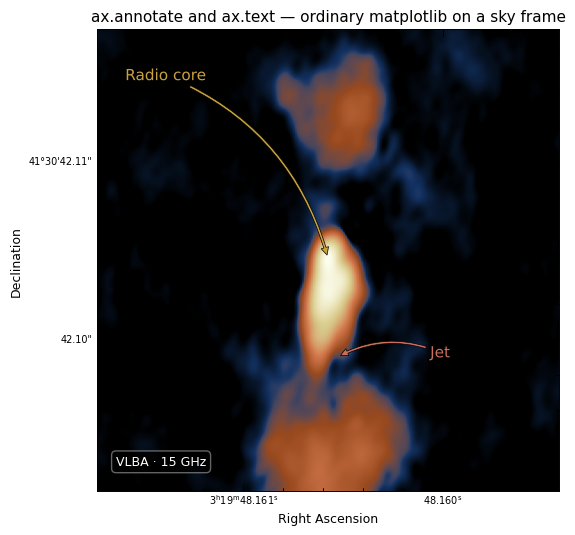

In [14]:
ax = show_3c84()
_jet = _WCS.pixel_to_world(_cx + 4, _cy - 55)       # a point partway down the jet
_arrow = dict(fc=C_RETICLE, ec="black", lw=0.5, shrinkA=1, shrinkB=4,
              arrowstyle="simple,tail_width=0.15", connectionstyle="arc3,rad=-0.25")

# Point at the core: sky coords for the target, axes fraction for the label.
ax.annotate("Radio core", xy=CORE, xycoords=ax.get_transform("world"),
            xytext=(0.06, 0.90), textcoords="axes fraction",
            color=C_RETICLE, fontsize=11, ha="left", va="center",
            arrowprops=_arrow, path_effects=stroke(2.0))

# A second arrow, curving the other way, onto the jet.
ax.annotate("Jet", xy=(_jet.ra.deg, _jet.dec.deg), xycoords=ax.get_transform("world"),
            xytext=(0.72, 0.30), textcoords="axes fraction",
            color=C_BEAM, fontsize=11, ha="left", va="center",
            arrowprops=dict(_arrow, fc=C_BEAM, connectionstyle="arc3,rad=0.25"),
            path_effects=stroke(2.0))

# A plain axes-fraction caption, in a box.
ax.text(0.04, 0.05, "VLBA · 15 GHz", transform=ax.transAxes, fontsize=9,
        color="white", ha="left", va="bottom",
        bbox=dict(boxstyle="round,pad=0.35", fc="black", ec="0.6", alpha=0.65))
ax.set_title("ax.annotate and ax.text — ordinary matplotlib on a sky frame",
             fontsize=11)

## 2. Measurement tools

Furniture *describes* the figure; the measurement tools let the reader take
numbers off it. Two of them — the **reticle** (mark a target) and the **ruler**
(measure between two points) — plus the one question they both have to answer first:
what do the numbers you hand them mean?

### What a bare tuple means

A plain numeric pair like `(83.6, 22.0)` is ambiguous: is it a *sky position* or a
*pixel position*? Both the reticle and the ruler settle it the same way, with a
`coord_type=` argument:

| `coord_type` | A numeric pair means |
| --- | --- |
| `'auto'` (ruler default) | sky degrees on a frame with a WCS; plain data coordinates otherwise |
| `'world'` (reticle default) | sky degrees — needs a frame with a WCS |
| `'pixel'` | image pixels, whatever the frame is |

So on a sky frame the two agree: hand either one `(83.6, 22.0)` and it lands at
RA 83.6°, Dec +22°. Reach for `coord_type='pixel'` when you are placing something
against the *image* rather than the sky — a bar beside a feature you can see, which
is exactly what the rulers in this tutorial do.

Below, the **same bar is drawn twice**: once from two sky positions, once from the
two pixel positions those map to. The result is identical — the only difference is
which language the numbers are written in, and `coord_type=` is how you say which.

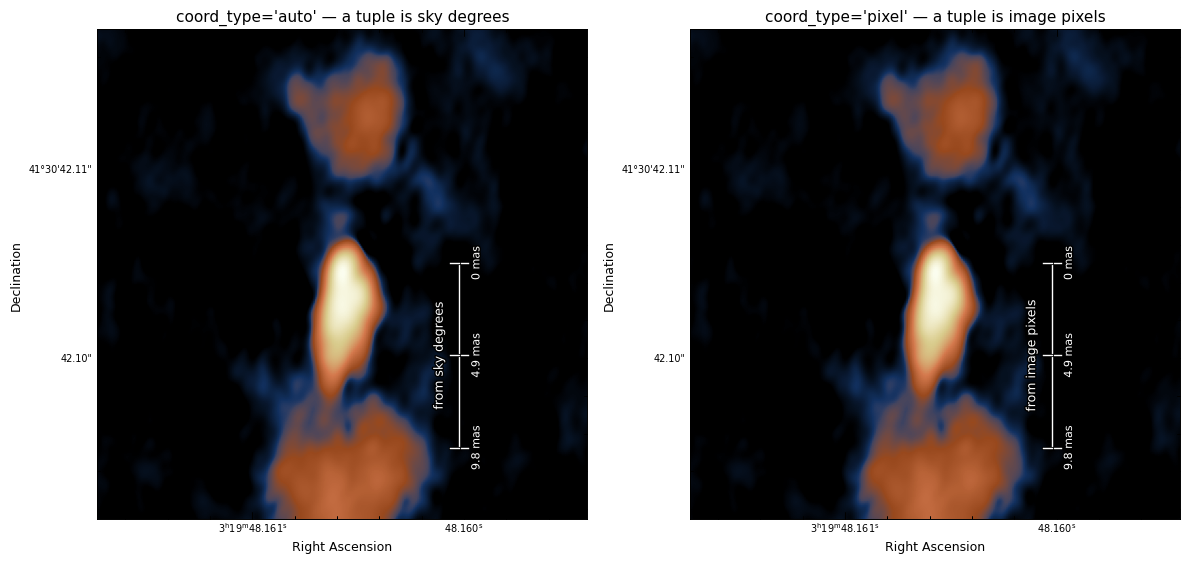

In [15]:
fig = plt.figure(figsize=(12, 6))

# The one bar, in two languages: pixel endpoints, and the sky positions they map to.
_p1, _p2 = (_cx + 62, _cy + 6), (_cx + 62, _cy - 92)
_s1, _s2 = _WCS.pixel_to_world(*_p1), _WCS.pixel_to_world(*_p2)
_w1 = (_s1.ra.deg, _s1.dec.deg)
_w2 = (_s2.ra.deg, _s2.dec.deg)

ax1 = show_3c84((1, 2, 1), fig=fig)
image_ruler(ax1, _w1, _w2, coord_type="auto", n_ticks=3,
            title="from sky degrees", title_fontsize=9, title_color="white")
ax1.set_title("coord_type='auto' — a tuple is sky degrees", fontsize=11)

ax2 = show_3c84((1, 2, 2), fig=fig)
image_ruler(ax2, _p1, _p2, coord_type="pixel", n_ticks=3,
            title="from image pixels", title_fontsize=9, title_color="white")
ax2.set_title("coord_type='pixel' — a tuple is image pixels", fontsize=11)

fig.tight_layout()

> **Note:** a `SkyCoord` is never ambiguous — pass one and it always means a sky
> position, whatever `coord_type` says. The `Ruler.from_world` and
> `Ruler.from_axes_fraction` constructors likewise fix the interpretation for you.

### Reticles

`add_reticle` marks a target in four styles — `'plus'`, `'x'`, `'L'`, and
`'circle'` — each with an automatic label side (it picks the side with more room)
and a stroke for legibility. The styles read differently against structure: an open
`'circle'` or `'L'` leaves the target itself unobscured, while `'plus'`/`'x'` point
right at it (top row). The `'L'` adds a `rotation=` knob that walks its *open*
quadrant around — point it away from the feature you don't want to hide, here the jet
(bottom row: `rotation=0/90/180/270` → open upper-right / upper-left / lower-left /
lower-right).

The target can be a numeric `(lon, lat)` tuple, a `SkyCoord`, or a position pulled
from the `SKY_POSITIONS` dict of well-known targets — e.g.
`sph.add_reticle(ax, sph.SKY_POSITIONS["galactic_center"], label="GC")`.

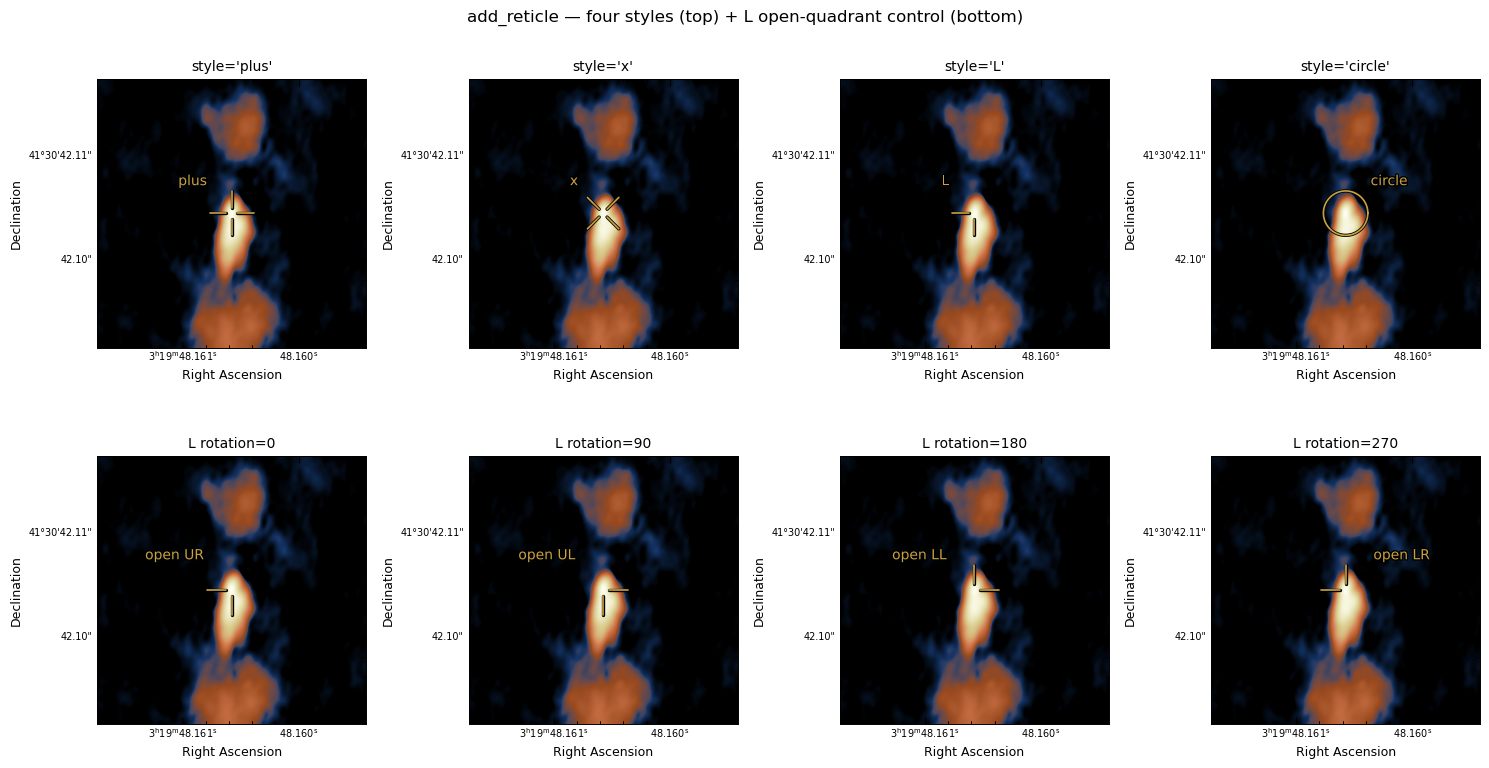

In [16]:
fig = plt.figure(figsize=(15, 8))
for i, style in enumerate(["plus", "x", "L", "circle"]):
    axr = show_3c84((2, 4, i + 1), fig=fig)
    sph.add_reticle(axr, CORE, style=style, size=16, color=C_RETICLE,
                    stroke_color="black", label=style, label_color=C_RETICLE,
                    label_fontsize=10,
                    label_kwargs=dict(path_effects=stroke(2.0)))
    axr.set_title(f"style={style!r}", fontsize=10)
for j, (rot, opens) in enumerate([(0, "UR"), (90, "UL"), (180, "LL"), (270, "LR")]):
    axr = show_3c84((2, 4, j + 5), fig=fig)
    sph.add_reticle(axr, CORE, style="L", rotation=rot, size=18, color=C_RETICLE,
                    stroke_color="black", label=f"open {opens}", label_color=C_RETICLE,
                    label_fontsize=10, label_kwargs=dict(path_effects=stroke(2.0)))
    axr.set_title(f"L rotation={rot}", fontsize=10)
fig.suptitle("add_reticle — four styles (top) + L open-quadrant control (bottom)",
             fontsize=12)
fig.tight_layout()

### Rulers

`Ruler` draws a measurement bar between two points with pixel-stable ticks. Its real
power is **unit handling**: it reads the pixel scale from the axes' WCS and labels in
angular units, auto-promoting by magnitude across the full range — `deg` → `arcmin` →
`arcsec` → `mas` → `μas` → `nas` — so this milliarcsecond field reads in `mas` with no
extra effort (pin it with `label_unit='mas'` if you prefer). With `convert=` it
relabels the ticks in *physical* units instead. On 3C 84 the jet is a few
milliarcseconds long; at the Perseus redshift that is a few parsecs. The left panel
reads the jet in mas; the right converts the same span to parsecs.

Both carry **minor ticks** between the labeled ones, exactly as a printed ruler does:
`minor_ticks='auto'` subdivides each major interval the way matplotlib's
`AutoMinorLocator` would, or pass an integer to choose the subdivision yourself
(`minor_ticks=5` puts four minors between each pair of labels). They are never
labeled, and `minor_tick_length` / `minor_tick_color` tune them if the defaults —
half the major length, the majors' color — need adjusting.

> **Note:** the unit is chosen once per ruler (from its largest tick), so every tick
> shares one unit — a single bar never mixes `mas` and `arcsec`.

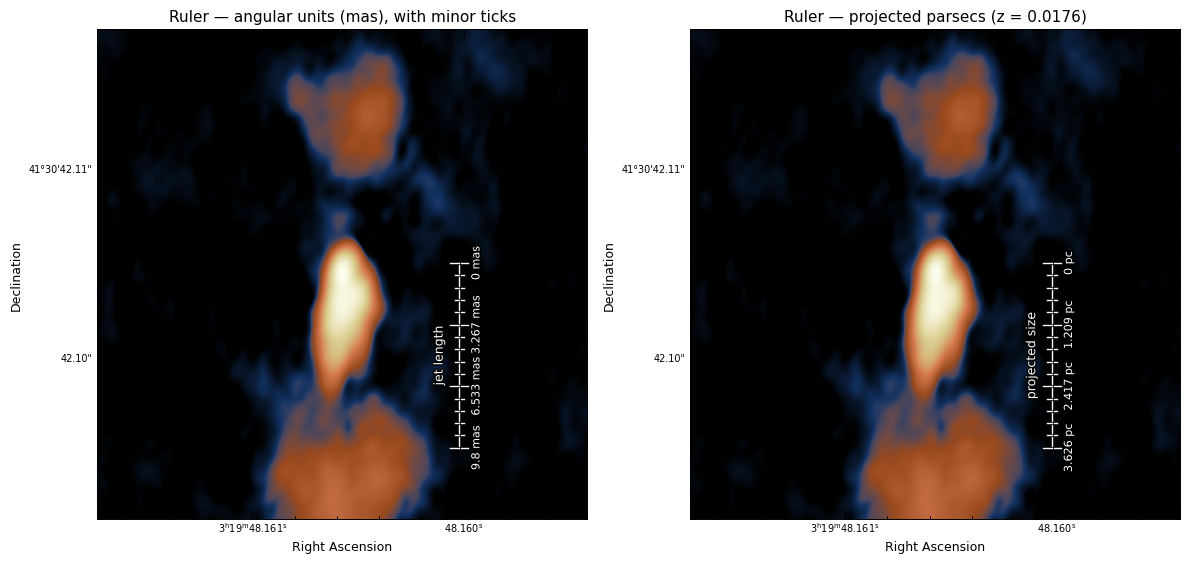

In [17]:
fig = plt.figure(figsize=(12, 6))

# Place the bar just east of the jet, over dark sky, so every tick label is legible —
# a measuring bar *beside* the feature, spanning the same vertical extent.
_jx = _cx + 62
ax1 = show_3c84((1, 2, 1), fig=fig)
image_ruler(ax1, (_jx, _cy + 6), (_jx, _cy - 92), minor_ticks="auto",
            title="jet length", title_fontsize=9, title_color="white")
ax1.set_title("Ruler — angular units (mas), with minor ticks", fontsize=11)

ax2 = show_3c84((1, 2, 2), fig=fig)
image_ruler(ax2, (_jx, _cy + 6), (_jx, _cy - 92), minor_ticks="auto",
            convert=dict(redshift=PERSEUS_Z, unit="pc"),
            title="projected size", title_fontsize=9, title_color="white")
ax2.set_title(f"Ruler — projected parsecs (z = {PERSEUS_Z})", fontsize=11)

fig.tight_layout()

**More ruler tricks.** A ruler is not only a scale bar:

- **Geodesic** — `geodesic=True` traces the on-sky *great-circle* path between two
  points (curved on a wide field), the correct measure of separation across the
  sphere.
- **Endcaps** — `endcap_style='arrow'` (or `'tick'`) caps the ends, with `endcaps=`
  choosing `'both'`, `'start'`, or `'end'` — the classic double-arrow
  "distance between two targets" look.
- **Twin offset axis** — `Ruler.from_axes_fraction` pins endpoints in axes
  fractions (0–1), so a ruler becomes a movable spine just outside the frame; with
  `lambda0=0.5` the zero sits at center and labels read ±offsets. Stack two — one in
  arcsec, one converted to kpc — for a publication twin-axis.

Here both: a geodesic double-arrow ruler on a wide field, and a pair of stacked
twin spines.

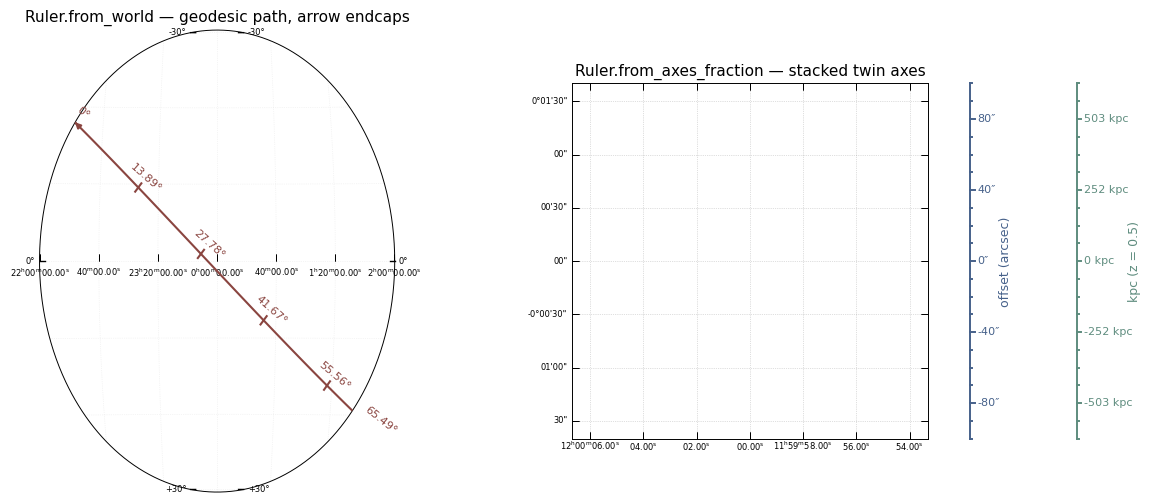

In [18]:
fig = plt.figure(figsize=(12, 6))

# Left: a geodesic great-circle ruler between two sky positions, arrow-capped.
axw = sph.make_wcs_frame((1, 2, 1), "AIT", center=(0.0, 0.0), fig=fig,
                         cdelt=0.6, npix=(100, 100))
axw.figure.canvas.draw()
axw.grid(True, color="0.85", lw=0.5)
sph.Ruler.from_world(SkyCoord(-25, -18, unit="deg"), SkyCoord(28, 22, unit="deg"),
                     ax=axw, geodesic=True, n_geodesic_pts=64, color=URAN[5], lw=1.5,
                     endcap_style="arrow", endcaps="both",
                     tick_side="both", label_fontsize=8).add_to(axw)
axw.set_title("Ruler.from_world — geodesic path, arrow endcaps", fontsize=11)

# Right: stacked twin offset spines (arcsec + kpc) outside a tangent field.
axt = sph.make_wcs_frame((1, 2, 2), "TAN", center=(180.0, 0.0), fig=fig,
                         cdelt=2.0 / 3600.0, npix=(100, 100))
axt.figure.canvas.draw()
twin = dict(tick_side="right", label_side="right", label_rotation="horizontal",
            title_side="right", title_beyond_labels=True, lambda0=0.5)
# label_unit is pinned: 'auto' would promote this 200″ span to arcmin, and
# tick_interval= is read in whatever unit gets resolved — so the bar would end up
# labeled in awkward fractions of an arcmin instead of the round 40″ steps we asked for.
sph.Ruler.from_axes_fraction((1.12, 0.0), (1.12, 1.0), ax=axt, tick_interval=40.0,
                             label_unit="arcsec", minor_ticks=4, color=URAN[0], lw=1.4,
                             title="offset (arcsec)",
                             title_fontsize=9, label_fontsize=8, **twin).add_to(axt)
sph.Ruler.from_axes_fraction((1.42, 0.0), (1.42, 1.0), ax=axt, tick_interval=40.0,
                             convert=dict(redshift=0.5, unit="kpc"), fmt="%.0f",
                             minor_ticks=4, color=URAN[4], lw=1.4, title="kpc (z = 0.5)",
                             title_fontsize=9, label_fontsize=8, **twin).add_to(axt)
axt.set_title("Ruler.from_axes_fraction — stacked twin axes", fontsize=11)

fig.subplots_adjust(left=0.06, right=0.80, wspace=0.5)

**A Ruler can stand in for a twin axis.** A matplotlib twin axis (`ax.twinx()`) is a
whole second Axes you create and keep in sync by hand. A Ruler pinned to the right
spine with `Ruler.from_axes_fraction((1.0, 0), (1.0, 1))` gives the same right-hand
scale in *one call* — it lands exactly on a fixed-aspect image's edge, reads in
pixel-stable ticks, and can convert units or stack (above). Both panels below put the
same mas-offset scale on the right of the 3C 84 field.

A few knobs make the Ruler read like a real axis. Each part of it picks its own
side, measured relative to the `xy1 → xy2` direction: `tick_side` (`'both'` by
default, or `'left'`/`'right'`/`'none'`), `label_side` (`'auto'` follows the ticks),
and `title_side` (`'auto'` sits opposite the labels). Below, `tick_side='left'` turns
the ticks **inward** over the image while the labels stay outside on the right, and
`minor_ticks='auto'` — the same knob as above — subdivides them. Minor ticks inherit
the majors' side and color unless `minor_tick_side` / `minor_tick_color` say
otherwise, so the inward-turned, image-legible white carries over for free.

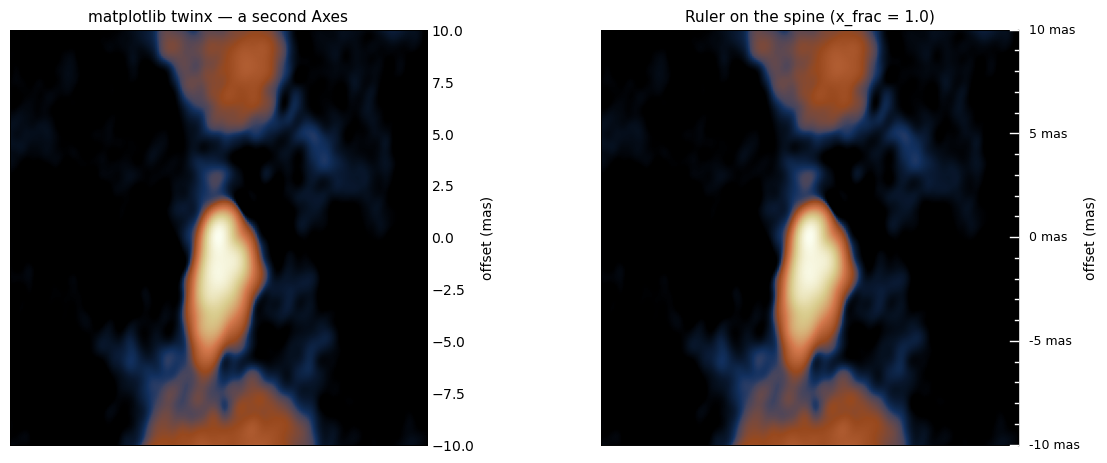

In [19]:
fig, (axA, axB) = plt.subplots(1, 2, figsize=(12, 5.0))
_cr = (_cx - 100, _cx + 100, _cy - 100, _cy + 100)
_mas_px = abs(_hdr_wcs["CDELT2"]) * 3600.0 * 1e3       # mas per pixel
# The spine scale sits outside the image, so give it the frame's own axis colors
# (read live from the active style) — exactly like a real twin axis would have. The
# ticks turn inward over the image, so they take a light color instead.
_axis_c = plt.rcParams["axes.edgecolor"]
_text_c = plt.rcParams["text.color"]
# aspect='auto' on both panels: a twinned axes cannot keep imshow's 'equal' aspect
# (shared axes forbid box adjustment), so pinning both to 'auto' is what keeps the two
# panels the same size.
_show = dict(origin="lower", cmap="sph.deepsky", aspect="auto", norm=mojave_norm())

# Left: the conventional matplotlib twin axis — a second Axes, y-limits mapped by hand.
axA.imshow(_data, **_show)
axA.set(xlim=_cr[:2], ylim=_cr[2:], xticks=[], yticks=[])
axT = axA.twinx()
axT.set_ylim((_cr[2] - _cy) * _mas_px, (_cr[3] - _cy) * _mas_px)
axT.set_ylabel("offset (mas)")
axT.yaxis.set_minor_locator(mticker.AutoMinorLocator())
axA.set_title("matplotlib twinx — a second Axes", fontsize=11)

# Right: a Ruler pinned to the right spine — one call, same readout.
axB.imshow(_data, **_show)
axB.set(xlim=_cr[:2], ylim=_cr[2:], xticks=[], yticks=[])
sph.Ruler.from_axes_fraction((1.0, 0.0), (1.0, 1.0), ax=axB,
                             pixscale_asec=abs(_hdr_wcs["CDELT2"]) * 3600.0,
                             lambda0=0.5, n_ticks=5, minor_ticks="auto",
                             tick_length=6.0, minor_tick_length=2.0,
                             tick_side="left", tick_color="white", color=_axis_c,
                             label_side="right", label_rotation="horizontal",
                             title="offset (mas)", title_side="right",
                             title_beyond_labels=True, label_color=_text_c,
                             title_color=_text_c, label_fontsize=9,
                             title_fontsize=10).add_to(axB)
axB.set_title("Ruler on the spine (x_frac = 1.0)", fontsize=11)
# Explicit boxes: tight_layout would shrink whichever panel carries more decoration.
fig.subplots_adjust(left=0.04, right=0.88, top=0.90, bottom=0.07, wspace=0.42)

> **Note:** these rulers and reticles measure distances *on the data*. Relabeling
> the **axes** themselves in offset or VLBI coordinates (a mas-from-center tick
> scale) is a different tool — the offset-tick treatment in
> [Decorating Frames](decorating_frames.ipynb).

## 3. Putting it together

Every tool in this tutorial, on one figure, on a *different* image — so the path to
your own work is concrete. This is **SN 1987A** seen by ALMA at 315 GHz: the warm
dust forged in the supernova's ejecta, glowing inside the famous ring, in the Large
Magellanic Cloud (the ALMA dust maps are from
[Cigan et al. 2019](https://ui.adsabs.harvard.edu/abs/2019ApJ...886...51C)). A
different facility (a sub-mm interferometer, not VLBI), a
different distance (≈ 51.4 kpc) — and the same toolkit furnishes it. We lay on a
two-band **`BeamStack`**, an angular **scale bar**, a **compass**, a **colorbar**,
two sets of sigma **contours**, a **reticle** on the supernova, and a **ruler** that
reads the structure straight out in parsecs.

The **image** and **white contours** are ALMA Band 7 (315 GHz); the **teal
contours** are a *second* dataset — the higher-resolution Band 9 (679 GHz) map, whose
tighter beam resolves the compact dust core. Overlaying a second image's contours is
the same `add_contour_overlay` call; because both ALMA bands already live on one
pixel grid, no reprojection is needed.

> **Note:** pick contour levels against each map's *own* noise and peak — here
> 5σ/10σ outlines the Band 7 emission, while the just-detected Band 9 core gets a
> 3σ/5σ pair (its 10σ would already exceed the map's peak). The full contour and
> colorbar story (σ ladders, `make_norm` so the bar reads true values) is in
> [FITS Images & Quicklook](fits_images.ipynb).

Text(0.5, 1.0, 'SN 1987A (ALMA 315 GHz) — fully furnished and measured')

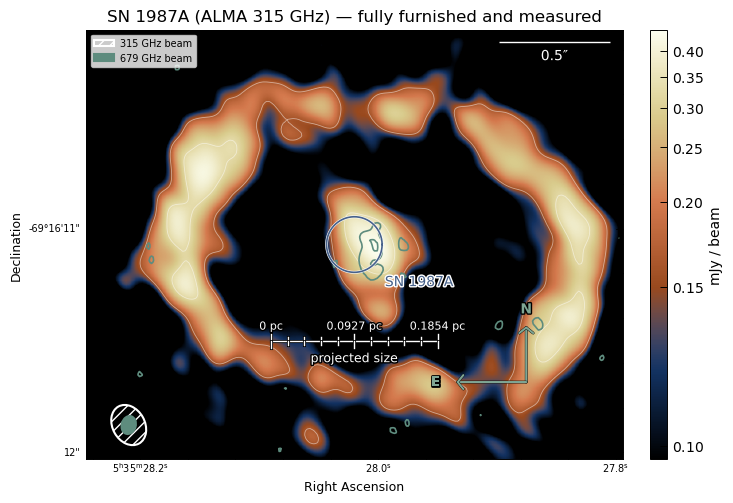

In [20]:
# A fresh image for the capstone: SN 1987A, ALMA 315 GHz (Band 7).
SN_FITS = "../../examples/data/sn1987a_alma_315GHz.fits"
SN_DIST_KPC = 51.4                                # LMC distance → physical scale
_sd, _sh = fits.getdata(SN_FITS, header=True)
_sd = np.squeeze(_sd) * 1e3                       # Jy/beam → mJy/beam (a tidy colorbar)
_shw = _sh.copy()
_shw.pop("DATE-OBS", None)
_SWCS = WCS(_shw).celestial
_srms = np.nanstd(_sd[:120, :120])                # off-source noise from a corner
_scx, _scy = _sh["CRPIX1"] - 1, _sh["CRPIX2"] - 1   # SN position = ring center

fig = plt.figure(figsize=(7.5, 7))
ax = fig.add_subplot(111, projection=_SWCS)
# Clipping at 3σ drops the noise floor to black, and an asinh stretch lifts the ring
# without blowing out the ejecta dust at the center — both structures read at once.
norm = sph.make_norm(stretch="asinh", vmin=3 * _srms, vmax=float(np.nanmax(_sd)))
im = ax.imshow(_sd, origin="lower", cmap="sph.deepsky", norm=norm)
ax.set_xlim(_scx - 200, _scx + 200)          # wide enough to take in the whole ring
ax.set_ylim(_scy - 160, _scy + 160)
for ci, name in ((0, "Right Ascension"), (1, "Declination")):
    ax.coords[ci].set_axislabel(name, fontsize=9)
    ax.coords[ci].set_ticklabel(fontsize=7)
    ax.coords[ci].set_ticks(number=3)
fig.canvas.draw()

# Sigma contours of the displayed Band 7 emission (white), then a SECOND dataset on
# top: the higher-resolution ALMA Band 9 (679 GHz) map (teal), which resolves the
# compact dust core. add_contour_overlay takes each as (world lon, lat, values); the
# two ALMA bands already share a pixel grid, so no reprojection is needed. Levels are
# set against each map's own noise and peak: 5σ/10σ for Band 7, 3σ/5σ for the
# just-detected Band 9 core.
_yy, _xx = np.mgrid[0:_sd.shape[0], 0:_sd.shape[1]]
_lon, _lat = _SWCS.wcs_pix2world(_xx, _yy, 0)
sph.add_contour_overlay(ax, _lon, _lat, _sd, levels=[5 * _srms, 10 * _srms],
                        colors="white", linewidths=0.6, alpha=0.5)

_s9d, _s9h = fits.getdata("../../examples/data/sn1987a_alma_679GHz.fits", header=True)
_s9d = np.squeeze(_s9d) * 1e3
_s9hw = _s9h.copy()
_s9hw.pop("DATE-OBS", None)
_l9, _b9 = WCS(_s9hw).celestial.wcs_pix2world(_xx, _yy, 0)
_s9rms = np.nanstd(_s9d[:120, :120])
sph.add_contour_overlay(ax, _l9, _b9, _s9d, levels=[3 * _s9rms, 5 * _s9rms],
                        colors=C_BAND9, linewidths=1.2)

# The full kit. The beam is now a BeamStack of both bands' resolutions (Band 9 is the
# tighter, higher-frequency one), color-matched to their contours.
_aspp = abs(_shw["CDELT2"]) * 3600.0


def _bpix(hh, key):
    return hh[key] * 3600.0 / _aspp


# The larger Band 7 beam reads as a hatched outline; the smaller Band 9 beam as a
# filled crossgrid — so the two resolutions stay distinguishable where they nest.
sph.BeamStack.from_specs(
    [dict(bmaj_pix=_bpix(_sh, "BMAJ"), bmin_pix=_bpix(_sh, "BMIN"), bpa_deg=_sh["BPA"],
          ec="white", style="hatch", label="315 GHz beam"),
     dict(bmaj_pix=_bpix(_s9h, "BMAJ"), bmin_pix=_bpix(_s9h, "BMIN"), bpa_deg=_s9h["BPA"],
          ec=C_BAND9, fc=C_BAND9, style="filledgrid", label="679 GHz beam")],
    ax=ax, fc="none", lw=1.5).add_to(ax)
ax.legend(loc="upper left", fontsize=7, framealpha=0.8)
sph.add_sizebar_asec(ax, _sh, length_asec=0.5, label='0.5″', color="white", loc=1)
sph.add_compass(ax, loc="lower right", color=C_COMPASS, stroke_color="black", length=0.13)
sph.add_colorbar(im, ax=ax, label="mJy / beam")
_sn = _SWCS.pixel_to_world(_scx, _scy)
# This reticle sits entirely on the pale core, so the usual gold accent would vanish —
# pick the annotation color against what it actually sits on (a deep blue here).
sph.add_reticle(ax, (_sn.ra.deg, _sn.dec.deg), style="circle", size=20, color=URAN[0],
                stroke_color="white", stroke_lw=2.0, label="SN 1987A", label_color=URAN[0],
                label_kwargs=dict(path_effects=stroke(2.0, "white")))
image_ruler(ax, (_scx - 62, _scy - 72), (_scx + 62, _scy - 72), n_ticks=3,
            minor_ticks="auto",
            convert=dict(distance=SN_DIST_KPC, distance_unit="kpc", unit="pc"),
            title="projected size", title_fontsize=9, title_color="white")
ax.set_title("SN 1987A (ALMA 315 GHz) — fully furnished and measured", fontsize=12)

That is the whole annotation toolkit working together: the beam fixes the
resolution, the scale bar and compass orient the field, the colorbar reads the
brightness, the contours trace the emission, the reticle marks the source, and the
ruler turns an on-sky angle into a physical size — all on an image you brought
yourself. From here, point any of these at your own figures.

## 4. Where to go next

This tutorial furnished and measured a single image. The natural next steps:

| If you want to… | Go to |
| --- | --- |
| adjust the image *itself* — stretch, colorbar, contours | [FITS Images & Quicklook](fits_images.ipynb) |
| style the frame's **own** ticks, grids, labels, and offset axes | [Decorating Frames](decorating_frames.ipynb) |
| draw planes, great circles, and **regions** as data | [Regions & Spherical Polygons](regions.ipynb) |
| zoom in with **inset axes** and connector lines | [Insets and Zoom Axes](insets_and_zoom.ipynb) |
| place image stamps and **rotatable markers** (antennas, planets, the Sun) | [Markers — Rotatable and Image Stamps](markers.ipynb) |
| understand the projection/frame landscape underneath | [A Tour of Projections](projections.ipynb) |

Reference: the annotation helpers are documented in the
[Overlays & annotations guide](../guide/overlays.md).